In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from sklearn.ensemble import RandomForestClassifier

In [2]:
DATA_DIR = Path("../data/processed")

dataset = pd.read_parquet(
    DATA_DIR / "forecast_dataset.parquet"
)

dataset.shape

(43188, 152)

In [3]:
drop_cols = [
    "DATETIME",
    "MJD",
    "ISOT",
]

X = dataset.drop(
    columns=drop_cols + ["flare_next_10min"],
    errors="ignore",
)

y = dataset["flare_next_10min"]

In [4]:
X = X.fillna(0)

(34550, 148)
(8638, 148)


In [7]:
X.select_dtypes(exclude=["number"]).columns.tolist()

['ROWID']

In [8]:
X = dataset.drop(
    columns=["flare_next_10min"],
    errors="ignore",
)

# Keep only numeric columns
X = X.select_dtypes(include=["number"])

# Fill missing values
X = X.fillna(0)

y = dataset["flare_next_10min"]

In [9]:
print(X.shape)

print(
    X.select_dtypes(exclude=["number"]).columns
)

(43188, 148)
Index([], dtype='str')


In [12]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [13]:
print(X_train.shape)
print(X_test.shape)

print(X_train.dtypes.unique())

(34550, 148)
(8638, 148)
[dtype('float64') dtype('int64')]


In [14]:
print(y_train.value_counts())
print()
print(y_test.value_counts())

flare_next_10min
0    32667
1     1883
Name: count, dtype: int64

flare_next_10min
0    8038
1     600
Name: count, dtype: int64


In [15]:
print(X_train.select_dtypes(exclude=["number"]).columns.tolist())

[]


In [16]:
print(X_train.dtypes[X_train.dtypes == "object"])

Series([], dtype: object)


In [39]:
drop_cols = [
    "flare_next_10min",

    # datetime
    "DATETIME",
    "ISOT",

    # IDs / metadata
    "MJD",
    "mjd",
    "MID_TIME",
    "SPEC_NUM",
    "TSTART",
    "TSTOP",

    "l0recnum",
    "l0framecnt",
    "pagestim",
    "l0dhobt",
    "lastevtmjd",
    "l0utcmin",
    "l0grtmin",
]





In [40]:
leakage_cols = [
    "flare_candidate",
    "strong_peak",
    "is_peak",
    "peak_rank",
    "peak_height",
    "peak_prominence",
    "peak_width",
    "integrated_counts",
]

In [41]:
X = dataset.drop(
    columns=drop_cols + leakage_cols,
    errors="ignore"
)

y = dataset["flare_next_10min"]

In [42]:
X = X.select_dtypes(include=["number"])
X = X.fillna(0)

In [43]:
print(X.shape)

(43188, 127)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

In [45]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [46]:
prob = rf.predict_proba(X_test)[:, 1]

pred = (prob >= 0.30).astype(int)

In [47]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      8141
           1       0.83      1.00      0.91       497

    accuracy                           0.99      8638
   macro avg       0.92      0.99      0.95      8638
weighted avg       0.99      0.99      0.99      8638

ROC-AUC: 0.999996539858238
[[8041  100]
 [   0  497]]


In [48]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      8038
           1       0.00      0.00      0.00       600

    accuracy                           0.93      8638
   macro avg       0.47      0.50      0.48      8638
weighted avg       0.87      0.93      0.90      8638

ROC-AUC : 0.7377815791656299
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
[[8038    0]
 [ 600    0]]


/home/rupali-jha/solar-flare-watch/ml/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rupali-jha/solar-flare-watch/ml/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rupali-jha/solar-flare-watch/ml/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [49]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance.head(20)

,Feature,Importance
126,cdte2ctr_rolling_mean,0.123398
125,cdte1ctr_rolling_mean,0.107370
100,yawradeg,0.081406
94,sunradeg,0.079881
95,sundecdeg,0.079150
124,czt2ctr_rolling_mean,0.056563
57,l0utchr,0.049216
52,l0grtsc,0.034819
101,yawdecdeg,0.030616
22,rolling_cv,0.024061


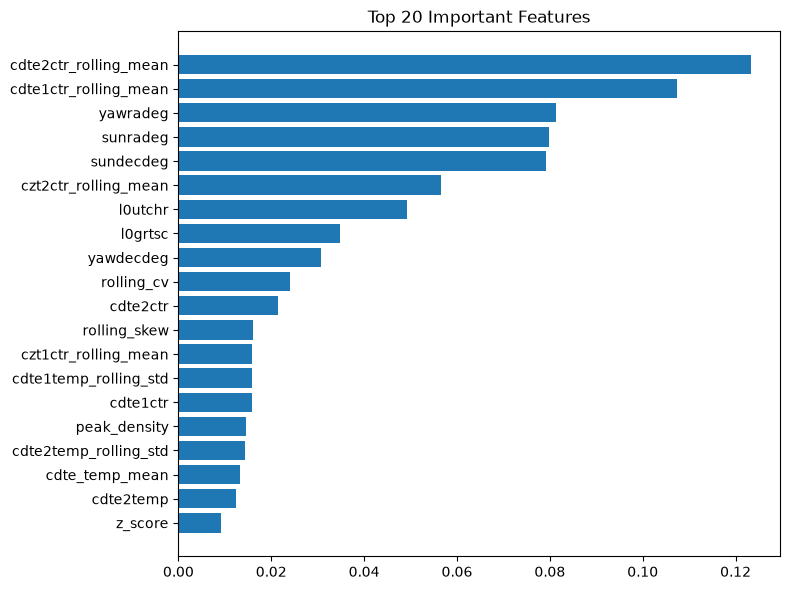

In [50]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(8,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [51]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump(rf, "../models/random_forest_flare_forecaster.pkl")

['../models/random_forest_flare_forecaster.pkl']

In [52]:
print(X.columns.tolist())

['COUNTS', 'STAT_ERR', 'rolling_mean', 'rolling_std', 'rolling_max', 'rolling_min', 'ema_10', 'ema_30', 'diff1', 'diff2', 'gradient', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'window_energy', 'window_variance', 'rolling_skew', 'rolling_kurtosis', 'rolling_rms', 'rolling_median', 'rolling_mad', 'rolling_cv', 'z_score', 'robust_z', 'peak_to_peak', 'local_energy', 'time_since_last_peak', 'rise_rate', 'decay_rate', 'peak_density', 'EXPOSURE', 'spec_total_counts', 'spec_mean_counts', 'spec_std_counts', 'spec_max', 'spec_min', 'peak_channel', 'spectral_centroid', 'spectral_spread', 'spectral_entropy', 'low_energy', 'mid_energy', 'high_energy', 'hardness_ratio1', 'hardness_ratio2', 'dominant_fraction', 'active_channels', 'l0grtyr', 'l0grtmon', 'l0grtdy', 'l0grthr', 'l0grtsc', 'l0grtmsc', 'l0utcyr', 'l0utcmon', 'l0utcdy', 'l0utchr', 'l0utcsc', 'l0utcmsc', 'czt1temp', 'czt2temp', 'czt1bunpxst', 'czt2bunpxst', 'cdte1ctr', 'pagenum', 'czt1ctr', 'czt1enth', 'czt2ctr', 'czt2enth', 'cdte2ctr', 'czt1pktm

In [53]:
prob = rf.predict_proba(X_test)[:, 1]

print(prob.min())
print(prob.max())
print(prob.mean())

0.0
0.99360022893821
0.08708063057768757


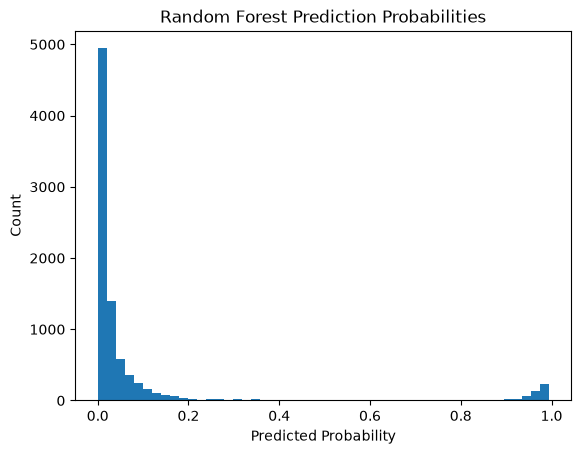

In [54]:
import matplotlib.pyplot as plt

plt.hist(prob, bins=50)
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest Prediction Probabilities")
plt.show()

In [55]:
from sklearn.metrics import classification_report

for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    pred = (prob >= t).astype(int)

    print(f"\nThreshold = {t}")
    print(classification_report(y_test, pred, zero_division=0))


Threshold = 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8141
           1       0.96      1.00      0.98       497

    accuracy                           1.00      8638
   macro avg       0.98      1.00      0.99      8638
weighted avg       1.00      1.00      1.00      8638


Threshold = 0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8141
           1       0.93      1.00      0.97       497

    accuracy                           1.00      8638
   macro avg       0.97      1.00      0.98      8638
weighted avg       1.00      1.00      1.00      8638


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      8141
           1       0.83      1.00      0.91       497

    accuracy                           0.99      8638
   macro avg       0.92      0.99      0.95      8638
weighted avg       0.99

In [56]:
prob = rf.predict_proba(X_test)[:, 1]

pred = (prob >= 0.5).astype(int)

In [57]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

print(classification_report(y_test, pred, zero_division=0))
print(confusion_matrix(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8141
           1       0.96      1.00      0.98       497

    accuracy                           1.00      8638
   macro avg       0.98      1.00      0.99      8638
weighted avg       1.00      1.00      1.00      8638

[[8119   22]
 [   0  497]]
ROC AUC: 0.999996539858238


In [58]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix")
print(cm)
print()

# Metrics
TPR = TP / (TP + FN)          # Recall / Sensitivity
FPR = FP / (FP + TN)          # False Positive Rate
TNR = TN / (TN + FP)          # Specificity
FNR = FN / (FN + TP)          # False Negative Rate
Precision = TP / (TP + FP)
Accuracy = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * Precision * TPR / (Precision + TPR)

print(f"TP  : {TP}")
print(f"TN  : {TN}")
print(f"FP  : {FP}")
print(f"FN  : {FN}")
print()

print(f"True Positive Rate (TPR)  : {TPR:.4f} ({TPR*100:.2f}%)")
print(f"False Positive Rate (FPR) : {FPR:.4f} ({FPR*100:.2f}%)")
print(f"True Negative Rate (TNR)  : {TNR:.4f} ({TNR*100:.2f}%)")
print(f"False Negative Rate (FNR) : {FNR:.4f} ({FNR*100:.2f}%)")
print(f"Precision                 : {Precision:.4f} ({Precision*100:.2f}%)")
print(f"Accuracy                  : {Accuracy:.4f} ({Accuracy*100:.2f}%)")
print(f"F1 Score                  : {F1:.4f}")

Confusion Matrix
[[8119   22]
 [   0  497]]

TP  : 497
TN  : 8119
FP  : 22
FN  : 0

True Positive Rate (TPR)  : 1.0000 (100.00%)
False Positive Rate (FPR) : 0.0027 (0.27%)
True Negative Rate (TNR)  : 0.9973 (99.73%)
False Negative Rate (FNR) : 0.0000 (0.00%)
Precision                 : 0.9576 (95.76%)
Accuracy                  : 0.9975 (99.75%)
F1 Score                  : 0.9783


In [59]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall (TPR)",
        "False Positive Rate (FPR)",
        "Specificity (TNR)",
        "False Negative Rate (FNR)",
        "F1 Score"
    ],
    "Value": [
        Accuracy,
        Precision,
        TPR,
        FPR,
        TNR,
        FNR,
        F1
    ]
})

display(metrics_df)

,Metric,Value
0,Accuracy,0.997453
1,Precision,0.957611
2,Recall (TPR),1.000000
3,False Positive Rate (FPR),0.002702
4,Specificity (TNR),0.997298
5,False Negative Rate (FNR),0.000000
6,F1 Score,0.978346


In [60]:
import joblib

joblib.dump(
    rf,
    "../models/solar_flare_forecaster.pkl"
)

['../models/solar_flare_forecaster.pkl']

In [62]:
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

importance.to_csv(
    RESULTS_DIR / "feature_importance.csv",
    index=False,
)

print("Feature importance saved successfully!")

Feature importance saved successfully!
